In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
# Step 1: Load the dataset
df = pd.read_csv('Week12_CreditCard.csv')
df= df.sample(10000)
# Explore the dataset
print(df.head())
print(df.info())
print(df.describe())

            Time        V1        V2        V3        V4        V5        V6  \
223416  143370.0  2.030709 -0.025594 -1.430831  0.133144  0.350571 -0.540941   
24224    33125.0 -0.364714  0.681821  1.356673  0.773130  0.356155 -0.130737   
48507    43676.0  1.310971  0.513613 -0.813105  0.773943  0.194081 -1.215744   
14742    25973.0  1.219489  0.570312 -0.472641  0.811092  0.018849 -1.263838   
47343    43179.0  1.179803 -0.819815 -0.055533 -0.486344 -0.768588 -0.590234   

              V7        V8        V9  ...       V21       V22       V23  \
223416  0.122521 -0.171189  0.235898  ...  0.305135  1.005686  0.026305   
24224   0.853487 -0.146141  0.209582  ... -0.008685  0.275196 -0.055920   
48507   0.278595 -0.184510  0.138179  ... -0.207308 -0.624301 -0.123541   
14742   0.273611 -0.151885 -0.354864  ... -0.095356 -0.282286 -0.063827   
47343  -0.217172 -0.179443 -0.761467  ...  0.240469  0.542260 -0.225802   

             V24       V25       V26       V27       V28  Amount  Cl

In [2]:
df['Class'].value_counts()

Class
0    9977
1      23
Name: count, dtype: int64

Text(0, 0.5, 'Count')

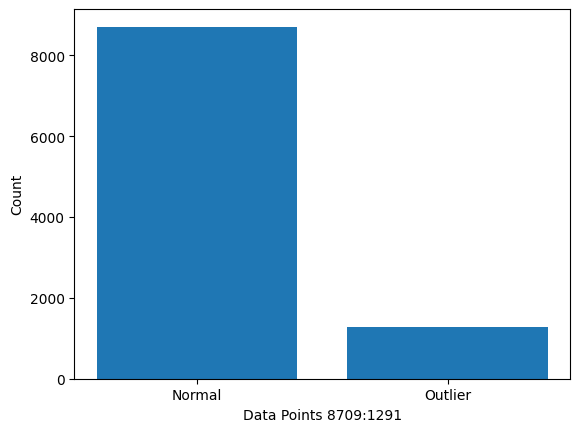

In [ ]:
# Step 2: Apply Z-score method for outlier detection
z_scores = np.abs(StandardScaler().fit_transform(df.drop('Class', axis=1)))
threshold = 3
# Identify outliers based on the threshold
outliers_zscore = (z_scores > threshold).any(axis=1)
# Visualize the number of outliers detected by Z-score method
plt.bar(['Normal'
,
'Outlier']
, [len(df) - outliers_zscore.sum(), outliers_zscore.sum()])
plt.xlabel(f'Data Points {len(df) -
outliers_zscore.sum()}:{outliers_zscore.sum()}')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

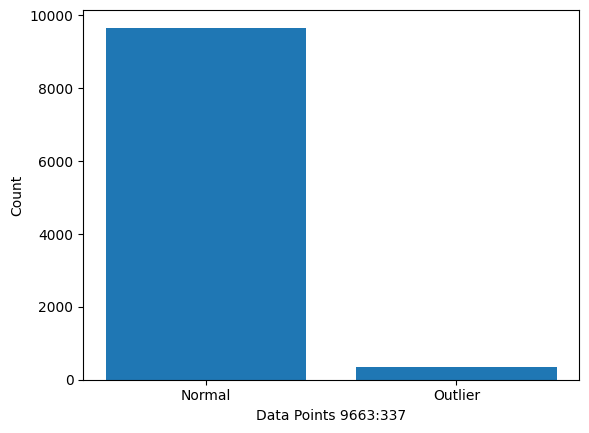

In [ ]:
threshold = 5
# Identify outliers based on the threshold
outliers_zscore = (z_scores > threshold).any(axis=1)
# Visualize the number of outliers detected by Z-score method
plt.bar(['Normal'
,
'Outlier']
, [len(df) - outliers_zscore.sum(), outliers_zscore.sum()])
plt.xlabel(f'Data Points {len(df) -
outliers_zscore.sum()}:{outliers_zscore.sum()}')
plt.ylabel('Count')

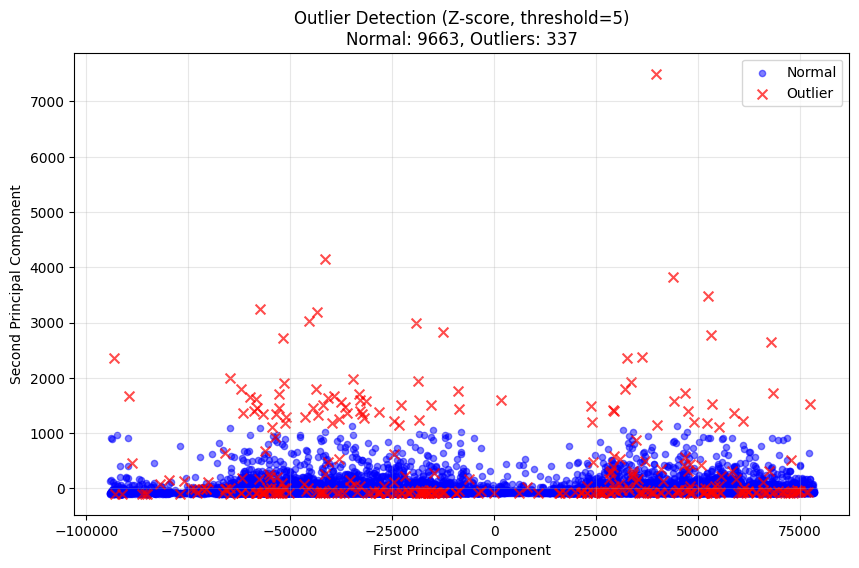

In [9]:
# Apply PCA for 2D visualization
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df.drop('Class', axis=1))

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df_pca[~outliers_zscore, 0], df_pca[~outliers_zscore, 1], 
            c='blue', label='Normal', alpha=0.5, s=20)
plt.scatter(df_pca[outliers_zscore, 0], df_pca[outliers_zscore, 1], 
            c='red', label='Outlier', alpha=0.7, s=50, marker='x')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title(f'Outlier Detection (Z-score, threshold={threshold})\nNormal: {(~outliers_zscore).sum()}, Outliers: {outliers_zscore.sum()}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# Step 3: Apply IQR method for outlier detection
Q1 = df.drop('Class', axis=1).quantile(0.25)
Q3 = df.drop('Class', axis=1).quantile(0.75)
IQR = Q3 - Q1
# Define the outlier range based on IQR
outlier_range_lower = Q1 - 1.5 * IQR
outlier_range_upper = Q3 + 1.5 * IQR
# Identify outliers based on the IQR range
outliers_iqr = ((df.drop('Class', axis=1) < outlier_range_lower) |
(df.drop('Class', axis=1) > outlier_range_upper)).any(axis=1)
# Visualize the number of outliers detected by IQR method

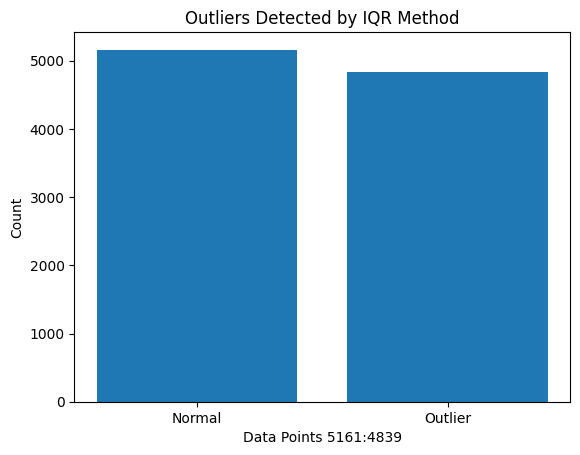

Class
0    4817
1      22
Name: count, dtype: int64

In [11]:
plt.bar(['Normal'
,
'Outlier']
, [len(df) - outliers_iqr.sum(), outliers_iqr.sum()])
plt.xlabel(f'Data Points {len(df) -
outliers_iqr.sum()}:{outliers_iqr.sum()}')
plt.ylabel('Count')
plt.title('Outliers Detected by IQR Method')
plt.show()
df[outliers_iqr]['Class'].value_counts()